In [1]:
import torch
import string
import torch.nn.functional as F

words=open("names.txt",'r').read().splitlines()
stoi = {c: i for i, c in enumerate(string.ascii_lowercase,start=1)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}

In [2]:
import random
block_size = 5
def build_dataset(words):
    X=[]
    Y=[]
    for w in words:
        context = block_size * [0]  
        for ch in w + ".":
            idx = stoi[ch]
            X.append(context)
            Y.append(idx)
            #print("".join(itos[i] for i in context),"-->",ch)
            context = context[1:]+ [idx]
            
    X=torch.tensor(X)
    Y=torch.tensor(Y)
    return X,Y

n1 = int(len(words) * 0.8)
n2 = int(len(words) * 0.9)
random.seed(42)
random.shuffle(words)
Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xtest,Ytest = build_dataset(words[n2:])

print(len(Xtr), len(Xdev), len(Xtest))

182625 22655 22866


In [3]:
#重置网络
C = torch.rand(27,5)
W = torch.rand(25,200)
b = torch.rand(200)
W2 = torch.rand(200,27)
b2 = torch.rand(27)
parameters = [C, W, b, W2, b2]
for p in parameters:
    p.requires_grad = True

In [4]:
total_params = sum(p.numel() for p in parameters)
print(f"总参数量: {total_params}")

总参数量: 10762


In [5]:
stepi = []
lossi = []

In [6]:

for i in range(50000):
    
    idxx = torch.randint(0,Xtr.shape[0],(32,))
    emb = C[Xtr[idxx]]
    h = torch.tanh(emb.view(-1,25) @ W + b)
    logit = h @ W2 + b2
    loss = F.cross_entropy(logit,Ytr[idxx])
    
    for p in parameters:
        p.grad = None
    
    loss.backward()

    if i<25000:
        lr = 0.1
    else:
        lr = 0.01
    for p in parameters:
        p.data += - lr * p.grad

    stepi.append(i+1)
    lossi.append(loss.item())   

print(loss.item())

2.2282004356384277


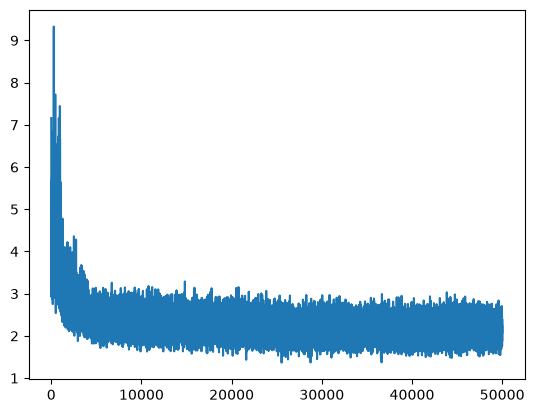

In [7]:
import matplotlib.pyplot as plt
plt.figure(1)
plt.plot(stepi,lossi)

In [8]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,25) @ W + b)
logit = h @ W2 + b2
loss = F.cross_entropy(logit,Ytr)
print(loss.item())

2.15396785736084


In [9]:
emb1 = C[Xdev]
h1 = torch.tanh(emb1.view(-1,25) @ W + b)
logit1 = h1 @ W2 + b2
loss1 = F.cross_entropy(logit1,Ydev)
print(loss1.item())

2.169234275817871


In [10]:
g = torch.Generator().manual_seed(42)

for _ in range(20):
    context = [0] * block_size
    out = []

    with torch.no_grad():
        for _ in range(30):  # 最多生成30个字符
            emb = C[torch.tensor([context])]
            h = torch.tanh(emb.view(1, -1) @ W + b)
            logits = h @ W2 + b2

            probs = F.softmax(logits, dim=1)
            idx = torch.multinomial(probs, 1, generator=g).item()

            if idx == 0:  # 生成结束符 '.'
                break

            out.append(itos[idx])
            context = context[1:] + [idx]

    print("".join(out))

yaesyahni
amen
leekten
manny
nilyahd
chenden
ellyandi
eryskeleanas
atoya
avayianus
lannez
jeoriah
rumoni
acelyn
adari
zeona
reen
kidanmali
eiounny
rinochan
